In [21]:
import kagglehub
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from collections import Counter
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')


In [22]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [23]:
# Нормализация
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [24]:
# Преобразование в плоский вид
x_train_flat = x_train.reshape((x_train.shape[0], 28*28)) # Результат: (60000, 784) - 60000 векторов длиной 784
x_test_flat = x_test.reshape((x_test.shape[0], 28*28))

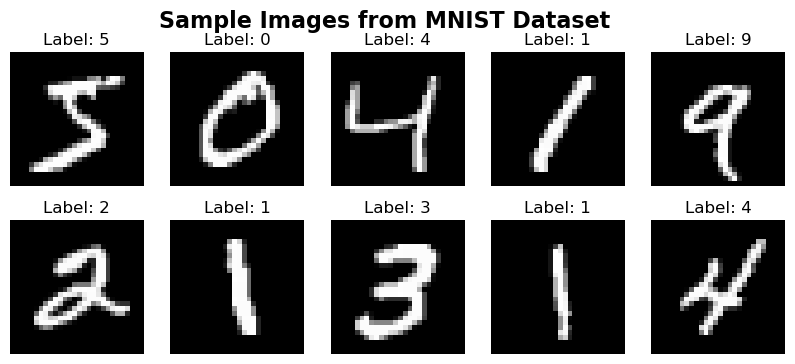

In [25]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sample Images from MNIST Dataset", fontsize=16, fontweight='bold')
plt.show()

In [26]:
# tensorflow 
class TensorFlowModel(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=10, batch_size=16, learning_rate=1e-3, validation_split=0.1):
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.validation_split = validation_split
        self.model = None

    def fit(self, X, y=None):
        self.model = keras.Sequential([
            keras.layers.Dense(128, activation='relu', input_shape=(784,)),
            keras.layers.Dense(64, activation='relu'),
            keras.layers.Dense(10, activation='softmax')
        ])

        self.model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=self.learning_rate),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=3,        #обучение прекратится через 3 эпохи без улучшения
            min_delta=0.001,
            restore_best_weights=True,
            verbose=0
        )

        self.model.fit(
            x=X,
            y=y,
            batch_size=self.batch_size,
            epochs=self.epochs,
            verbose=0,
            shuffle=True,
            validation_split=self.validation_split,
            callbacks=[early_stopping]
        )
        return self

    def predict(self, X):
        if self.model is None:
            raise ValueError("Модель не обучена")
        y_pred = self.model.predict(X, verbose=0)
        return np.argmax(y_pred, axis=1)

    def predict_proba(self, X):
        return self.model.predict(X, verbose=0)
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

In [27]:
tf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', TensorFlowModel(epochs=10, batch_size=16, learning_rate=1e-3))
])

In [28]:
#Обучение Tensorflow
tf_pipeline.fit(x_train_flat, y_train)
tf_train_acc = tf_pipeline.score(x_train_flat, y_train)
tf_test_acc = tf_pipeline.score(x_test_flat, y_test)

print(f"TensorFlow Train accuracy: {tf_train_acc:.4f}, Test accuracy: {tf_test_acc:.4f}")

TensorFlow Train accuracy: 0.9797, Test accuracy: 0.9647


In [29]:
#  pytorch 
class PyTorchNN(nn.Module):
    def __init__(self, input_size=784, hidden1=128, hidden2=64, num_classes=10):
        super(PyTorchNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class PyTorchModelWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, epochs=10, batch_size=16, learning_rate=1e-3, validation_split=0.1):
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.validation_split = validation_split
        self.model = None
        self.input_size = 784
        self.num_classes = 10

    def fit(self, X, y=None):
        
        self.model = PyTorchNN(input_size=self.input_size, num_classes=self.num_classes)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        
        # Разделение на train/val 
        if self.validation_split > 0:
            val_size = int(len(X) * self.validation_split)
            train_size = len(X) - val_size
            indices = np.random.permutation(len(X))
            train_idx, val_idx = indices[:train_size], indices[train_size:]
            
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
        else:
            X_train, X_val = X, None
            y_train, y_val = y, None
        
        # Конвертация в тензоры
        X_tensor = torch.FloatTensor(X_train)
        y_tensor = torch.LongTensor(y_train)
        
        dataset = TensorDataset(X_tensor, y_tensor)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        # Обучение
        self.model.train()
        best_val_acc = 0
        patience_counter = 0
        
        for epoch in range(self.epochs):
            epoch_loss = 0
            for batch_X, batch_y in dataloader:
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            
            # Валидация
            if X_val is not None:
                self.model.eval()
                with torch.no_grad():
                    val_tensor = torch.FloatTensor(X_val)
                    val_outputs = self.model(val_tensor)
                    val_pred = torch.argmax(val_outputs, dim=1)
                    val_acc = accuracy_score(y_val, val_pred.numpy())
                
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= 3:
                        break
                self.model.train()
        
        return self

    def predict(self, X):
        if self.model is None:
            raise ValueError("Модель не обучена")
        self.model.eval()
        X_tensor = torch.FloatTensor(X)
        with torch.no_grad():
            outputs = self.model(X_tensor)
            predictions = torch.argmax(outputs, dim=1)
        return predictions.numpy()

    def predict_proba(self, X):
        self.model.eval()
        X_tensor = torch.FloatTensor(X)
        with torch.no_grad():
            outputs = torch.softmax(self.model(X_tensor), dim=1)
        return outputs.numpy()
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

In [30]:
pytorch_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', PyTorchModelWrapper(epochs=10, batch_size=16, learning_rate=1e-3))
])

In [31]:
pytorch_pipeline.fit(x_train_flat, y_train)
pt_train_acc = pytorch_pipeline.score(x_train_flat, y_train)
pt_test_acc = pytorch_pipeline.score(x_test_flat, y_test)

print(f"PyTorch Train accuracy: {pt_train_acc:.4f}, Test accuracy: {pt_test_acc:.4f}")

PyTorch Train accuracy: 0.9846, Test accuracy: 0.9706


In [32]:
# Сохранение 
tf_pipeline.named_steps['classifier'].model.save('tf_mnist_model.h5')
print("\nTensorFlow модель сохранена как 'tf_mnist_model.h5'")


TensorFlow модель сохранена как 'tf_mnist_model.h5'


In [33]:
# Сохранение 
torch.save(pytorch_pipeline.named_steps['classifier'].model.state_dict(), 'pytorch_mnist_model.pth')
print("PyTorch модель сохранена как 'pytorch_mnist_model.pth'")

PyTorch модель сохранена как 'pytorch_mnist_model.pth'


In [34]:
import joblib
# Сохранение пайплайнов
joblib.dump(tf_pipeline, 'tf_pipeline.pkl')
torch.save(pytorch_pipeline.named_steps['classifier'].model.state_dict(), 'pytorch_weights.pth')
joblib.dump(pytorch_pipeline.named_steps['scaler'], 'pytorch_scaler.pkl')
print("Пайплайны сохранены")

Пайплайны сохранены


In [64]:
from tensorflow.keras.datasets import fashion_mnist
# Загрузка fashion MNIST
(x_train_f, y_train_f), (x_test_f, y_test_f) = fashion_mnist.load_data()

In [65]:
x_train_f = x_train_f.astype('float32') / 255
x_test_f = x_test_f.astype('float32') / 255

x_train_f_flat = x_train_f.reshape((x_train_f.shape[0], 28*28))
x_test_f_flat = x_test_f.reshape((x_test_f.shape[0], 28*28))

In [71]:
base_model = load_model('tf_mnist_model.h5')

In [72]:
# Замораживаем все слои, кроме последнего
for layer in base_model.layers[:-1]:
    layer.trainable = False


In [73]:
from tensorflow.keras.layers import Dense

# Добавляем новый выходной слой
x = base_model.layers[-2].output
new_output = Dense(10, activation='softmax')(x)

In [74]:
# Создаём новую модель
transfer_model = keras.Model(inputs=base_model.inputs[0], outputs=new_output)

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.fit(
    x_train_f_flat, y_train_f,
    batch_size=32,
    epochs=20,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

test_loss, test_acc = transfer_model.evaluate(x_test_f_flat, y_test_f)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2483 - loss: 2.0676 - val_accuracy: 0.4380 - val_loss: 1.7215
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5206 - loss: 1.5318 - val_accuracy: 0.5900 - val_loss: 1.3735
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6084 - loss: 1.2820 - val_accuracy: 0.6348 - val_loss: 1.1907
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6438 - loss: 1.1446 - val_accuracy: 0.6608 - val_loss: 1.0822
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6652 - loss: 1.0599 - val_accuracy: 0.6798 - val_loss: 1.0111
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6788 - loss: 1.0032 - val_accuracy: 0.6920 - val_loss: 0.9623
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6874 - loss: 0.9631 - val_accuracy: 0.7017 - val_loss: 0.9268
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6936 - loss: 0.9333 - 

In [75]:
transfer_model.save('transfer_learning_fashion_mnist.keras')